### Ruitenwissermechanisme — 7 stangen, 4 vaste punten
(*F. Ulloa Roas, H. Bruyninckx – aangepast voor 7-stangen ruitenwisser*)

**Structuur**
- Vaste (grond) punten: **A, D, i, H**
- Stang 1 (A → B) — *aandrijvende krukstang* met hoek θ₁ (input)
- Stang 2 (B → C) — koppelstang, hoek θ₂
- Stang 3 = star lichaam **K-E-C-D-F**, draaipunt D, hoek θ₃ (body x-as in richting D→K)
- Stang 4 (E → J) — synchronisatiestang, hoek θ₆
- Stang 5 = star lichaam **L-j-i**, draaipunt i, hoek θ₇ (body x-as in richting i→L)
- Stang 6 (F → G), hoek θ₄
- Stang 7 (G → H), hoek θ₅

**Drie onafhankelijke lussluitingen** (6 vergelijkingen, 6 onbekenden θ₂, θ₃, θ₄, θ₅, θ₆, θ₇):

| Lus | Vergelijking |
|---|---|
| 1 (A-B-C-D) | r₁ eⁱᶿ¹ + r₂ eⁱᶿ² − L\_DC eⁱᶿ³ = D − A |
| 2 (D-E-J-i) | L\_DE eⁱᶿ³ + r₄ eⁱᶿ⁶ − L\_iJ eⁱᶿ⁷ = i − D |
| 3 (D-F-G-H) | −L\_DF eⁱᶿ³ + r₆ eⁱᶿ⁴ − r₇ eⁱᶿ⁵ = H − D |

K en L zijn vrije uiteinden (wisserbladen), zonder kinematische rol — louter visualisatie.


In [79]:
# Bibliotheken
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

%matplotlib widget


In [80]:
# === Geometrie (SI: m, rad) === alle stangen op dezelfde schaal
# Vaste punten in wereldframe
grond_A = np.array([0.00, 0.00])
grond_D = np.array([0.76, 0.66])
grond_I = np.array([1.77, 0.66])
grond_H = np.array([1.79, 0.01])

# Stang-lengtes (binair)
r1 = 0.43   # stang 1: A -> B  (aandrijfkruk)
r2 = 0.67   # stang 2: B -> C  (koppelstang)
r4 = 1.01   # stang 4: E -> J  (synchronisatiestang)
r6 = 1.20   # stang 6: F -> G
r7 = 0.35   # stang 7: H -> G

# Stang 3 — body-frame coordinaten van joints t.o.v. D
# Body x-as wijst van D naar K (vrije top), body y-as ⟂ in CCW
L_DK = 1.12   # D -> K  (vrije top, alleen visualisatie)
L_DE = 0.29   # D -> E  (joint naar stang 4)
L_DC = 0.16   # D -> C  (joint naar stang 2; positief x = zelfde kant als K)
L_DF = 0.41   # D -> F  (joint naar stang 6; tegenoverliggende kant: negatief x)

# Stang 5 — body-frame coordinaten t.o.v. i
L_iL = 1.13   # i -> L  (vrije top, visualisatie)
L_iJ = 0.28   # i -> J  (joint naar stang 4)

# Afgeleide grondvectoren
rAD = grond_D - grond_A
rDI = grond_I - grond_D
rDH = grond_H - grond_D

print('Loop-1 Grashof check (A-B-C-D):')
bars1 = sorted([r1, r2, L_DC, np.linalg.norm(rAD)])
print(f'  s+l = {bars1[0]+bars1[3]:.3f},  p+q = {bars1[1]+bars1[2]:.3f}',
      '  →  Grashof' if bars1[0]+bars1[3] <= bars1[1]+bars1[2] else '  →  NIET Grashof')


Loop-1 Grashof check (A-B-C-D):
  s+l = 1.167,  p+q = 1.100   →  NIET Grashof


In [ ]:
# === Tijd-discretisatie en aandrijfprofiel ===
omega   = 1.5    # constante motorsnelheid [rad/s]  -> kan ook variabel
t_begin = 0.0
t_end   = 2*np.pi/omega    # 1 volledige omwenteling
Ts      = 0.02
t = np.arange(t_begin, t_end + Ts, Ts)

# driver: stang 1
theta1_mid = np.deg2rad(65)
amplitude  = np.deg2rad(29)        # speel met deze waarde tot net vóór het dode punt
theta1   = theta1_mid + amplitude * np.sin(omega * t)
dtheta1  =  amplitude * omega    * np.cos(omega * t)
ddtheta1 = -amplitude * omega**2 * np.sin(omega * t)

# Beginschattingen voor fsolve (eerste tijdstap)
theta2_init = np.deg2rad( 11)
theta3_init = np.deg2rad(120)
theta4_init = np.deg2rad(-27)   # stang 6
theta5_init = np.deg2rad(313)   # stang 7
theta6_init = np.deg2rad( 0)   # stang 4
theta7_init = np.deg2rad( 120)   # stang 5


In [82]:
# Rotatie van een 2D vector over hoek theta
def rotate_vector(z, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return R @ z


In [83]:
# === Positie-lussluiting: 6 vgl, 6 onbekenden ===
# x = [theta2, theta3, theta4, theta5, theta6, theta7]
#   theta3 = oriëntatie van stang 3 (D->K richting)
#   theta7 = oriëntatie van stang 5 (i->L richting)
def loop_closure_eqs(x, theta1,
                     r1, r2, r4, r6, r7,
                     L_DC, L_DE, L_DF, L_iJ,
                     rAD, rDI, rDH):
    th2, th3, th4, th5, th6, th7 = x
    # Lus 1: A-B-C-D
    F1 = r1*np.cos(theta1) + r2*np.cos(th2) + L_DC*np.cos(th3) - rAD[0]
    F2 = r1*np.sin(theta1) + r2*np.sin(th2) + L_DC*np.sin(th3) - rAD[1]
    # Lus 2: D-E-J-i
    F3 = L_DE*np.cos(th3) + r4*np.cos(th6) - L_iJ*np.cos(th7) - rDI[0]
    F4 = L_DE*np.sin(th3) + r4*np.sin(th6) - L_iJ*np.sin(th7) - rDI[1]
    # Lus 3: D-F-G-H
    F5 = -L_DF*np.cos(th3) + r6*np.cos(th4) - r7*np.cos(th5) - rDH[0]
    F6 = -L_DF*np.sin(th3) + r6*np.sin(th4) - r7*np.sin(th5) - rDH[1]
    return [F1, F2, F3, F4, F5, F6]


In [84]:
# === Volledige kinematica (positie / snelheid / versnelling) ===
def kinematics(r1, r2, r4, r6, r7, L_DC, L_DE, L_DF, L_iJ,
               rAD, rDI, rDH,
               theta1, dtheta1, ddtheta1,
               theta2_init, theta3_init, theta4_init,
               theta5_init, theta6_init, theta7_init, t):
    N = len(t)
    theta2  = np.zeros(N); theta3  = np.zeros(N); theta4  = np.zeros(N)
    theta5  = np.zeros(N); theta6  = np.zeros(N); theta7  = np.zeros(N)
    dtheta2 = np.zeros(N); dtheta3 = np.zeros(N); dtheta4 = np.zeros(N)
    dtheta5 = np.zeros(N); dtheta6 = np.zeros(N); dtheta7 = np.zeros(N)
    ddtheta2= np.zeros(N); ddtheta3= np.zeros(N); ddtheta4= np.zeros(N)
    ddtheta5= np.zeros(N); ddtheta6= np.zeros(N); ddtheta7= np.zeros(N)
    cond    = np.zeros(N)

    opt = {'full_output': True}

    for k in range(N):
        # ----- positiesluiting -----
        x0 = [theta2_init, theta3_init, theta4_init,
              theta5_init, theta6_init, theta7_init]
        x, _, ier, msg = fsolve(
            lambda x: loop_closure_eqs(x, theta1[k],
                                       r1, r2, r4, r6, r7,
                                       L_DC, L_DE, L_DF, L_iJ,
                                       rAD, rDI, rDH),
            x0, **opt)
        if ier != 1:
            print(f'fsolve k={k} ier={ier}: {msg}')
        theta2[k], theta3[k], theta4[k], theta5[k], theta6[k], theta7[k] = x

        t2,t3,t4,t5,t6,t7 = x
        # ----- snelheidssluiting:  A · dθ = b · dθ₁ -----
        # rij = ∂F_i/∂θ_j  voor onbekenden [t2, t3, t4, t5, t6, t7]
        A = np.array([
          [-r2*np.sin(t2), -L_DC*np.sin(t3), 0,             0,             0,            0           ],
          [ r2*np.cos(t2),  L_DC*np.cos(t3), 0,             0,             0,            0           ],
          [ 0,             -L_DE*np.sin(t3), 0,             0,            -r4*np.sin(t6), L_iJ*np.sin(t7)],
          [ 0,              L_DE*np.cos(t3), 0,             0,             r4*np.cos(t6),-L_iJ*np.cos(t7)],
          [ 0,              L_DF*np.sin(t3),-r6*np.sin(t4), r7*np.sin(t5), 0,            0           ],
          [ 0,             -L_DF*np.cos(t3), r6*np.cos(t4),-r7*np.cos(t5), 0,            0           ],
        ])
        b = np.array([ r1*np.sin(theta1[k])*dtheta1[k],
                      -r1*np.cos(theta1[k])*dtheta1[k],
                       0, 0, 0, 0])
        dth = np.linalg.solve(A, b)
        dtheta2[k], dtheta3[k], dtheta4[k], dtheta5[k], dtheta6[k], dtheta7[k] = dth
        cond[k] = np.linalg.cond(A)

        # ----- versnellingssluiting:  A · ddθ = c -----
        dt2,dt3,dt4,dt5,dt6,dt7 = dth
        c = np.array([
            # rij 1 (F1):
            r1*np.cos(theta1[k])*dtheta1[k]**2 + r1*np.sin(theta1[k])*ddtheta1[k]
            + r2*np.cos(t2)*dt2**2 + L_DC*np.cos(t3)*dt3**2,
            # rij 2 (F2):
            r1*np.sin(theta1[k])*dtheta1[k]**2 - r1*np.cos(theta1[k])*ddtheta1[k]
            + r2*np.sin(t2)*dt2**2 + L_DC*np.sin(t3)*dt3**2,
            # rij 3 (F3):
            L_DE*np.cos(t3)*dt3**2 + r4*np.cos(t6)*dt6**2 - L_iJ*np.cos(t7)*dt7**2,
            # rij 4 (F4):
            L_DE*np.sin(t3)*dt3**2 + r4*np.sin(t6)*dt6**2 - L_iJ*np.sin(t7)*dt7**2,
            # rij 5 (F5):
           -L_DF*np.cos(t3)*dt3**2 + r6*np.cos(t4)*dt4**2 - r7*np.cos(t5)*dt5**2,
            # rij 6 (F6):
           -L_DF*np.sin(t3)*dt3**2 + r6*np.sin(t4)*dt4**2 - r7*np.sin(t5)*dt5**2,
        ])
        ddth = np.linalg.solve(A, c)
        ddtheta2[k],ddtheta3[k],ddtheta4[k],ddtheta5[k],ddtheta6[k],ddtheta7[k] = ddth

        # carry-over voor volgende iteratie
        dt = (t[1]-t[0]) if N>1 else 0
        theta2_init = t2 + dt*dt2
        theta3_init = t3 + dt*dt3
        theta4_init = t4 + dt*dt4
        theta5_init = t5 + dt*dt5
        theta6_init = t6 + dt*dt6
        theta7_init = t7 + dt*dt7

    return (theta2, theta3, theta4, theta5, theta6, theta7,
            dtheta2,dtheta3,dtheta4,dtheta5,dtheta6,dtheta7,
            ddtheta2,ddtheta3,ddtheta4,ddtheta5,ddtheta6,ddtheta7,
            cond)


In [85]:
# === Run kinematica ===
(theta2, theta3, theta4, theta5, theta6, theta7,
 dtheta2,dtheta3,dtheta4,dtheta5,dtheta6,dtheta7,
 ddtheta2,ddtheta3,ddtheta4,ddtheta5,ddtheta6,ddtheta7,
 cond) = kinematics(
    r1, r2, r4, r6, r7, L_DC, L_DE, L_DF, L_iJ,
    rAD, rDI, rDH,
    theta1, dtheta1, ddtheta1,
    theta2_init, theta3_init, theta4_init,
    theta5_init, theta6_init, theta7_init, t)

print('Ranges over 1 omwenteling:')
for name, arr in [('θ2',theta2),('θ3',theta3),('θ4',theta4),
                  ('θ5',theta5),('θ6',theta6),('θ7',theta7)]:
    deg = np.rad2deg(arr)
    print(f'  {name}: min={deg.min():+6.1f}°  max={deg.max():+6.1f}°  Δ={deg.max()-deg.min():.1f}°')
print(f'Max cond(A) = {cond.max():.1f}  (zo dichter bij 1 hoe beter geconditioneerd)')


fsolve k=29 ier=5: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
fsolve k=30 ier=4: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
fsolve k=31 ier=4: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
fsolve k=32 ier=5: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
fsolve k=33 ier=4: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
fsolve k=34 ier=4: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
fsolve k=35 ier=4: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
fsolve k=36 ier=4: The iteration is not making good progress, as measu

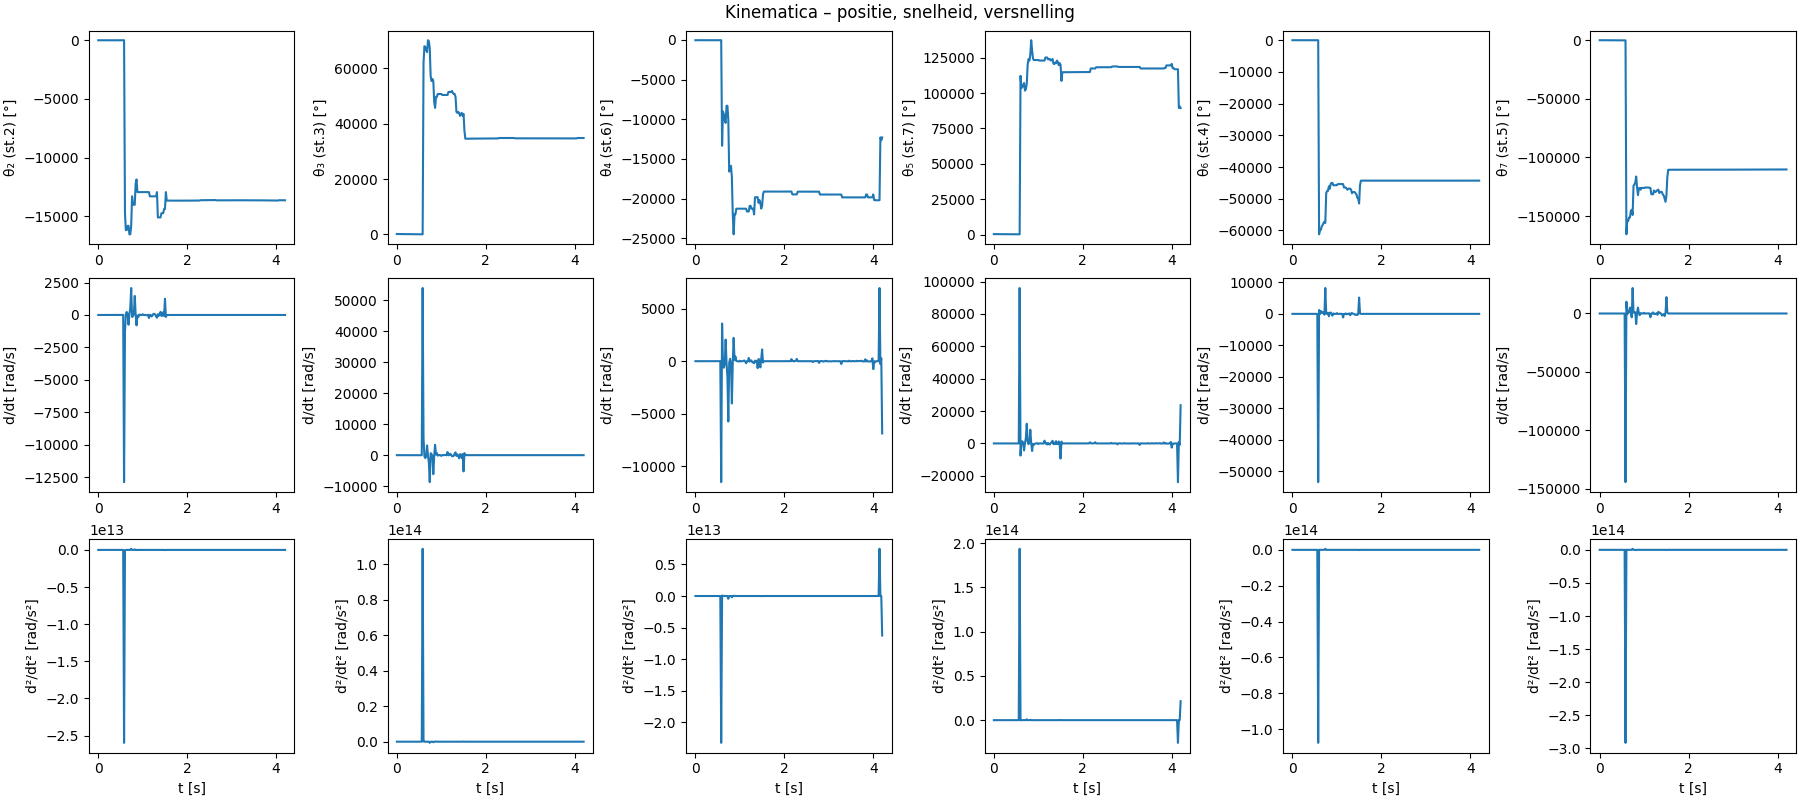

In [86]:
# === Plot positie / snelheid / versnelling ===
fig, ax = plt.subplots(3, 6, figsize=(18, 8), constrained_layout=True)
labels = ['θ₂ (st.2)', 'θ₃ (st.3)', 'θ₄ (st.6)', 'θ₅ (st.7)', 'θ₆ (st.4)', 'θ₇ (st.5)']
pos   = [theta2, theta3, theta4, theta5, theta6, theta7]
vel   = [dtheta2,dtheta3,dtheta4,dtheta5,dtheta6,dtheta7]
acc   = [ddtheta2,ddtheta3,ddtheta4,ddtheta5,ddtheta6,ddtheta7]

for i in range(6):
    ax[0,i].plot(t, np.rad2deg(pos[i]));  ax[0,i].set_ylabel(labels[i]+' [°]')
    ax[1,i].plot(t, vel[i]);              ax[1,i].set_ylabel('d/dt [rad/s]')
    ax[2,i].plot(t, acc[i]);              ax[2,i].set_ylabel('d²/dt² [rad/s²]')
    ax[2,i].set_xlabel('t [s]')
fig.suptitle('Kinematica – positie, snelheid, versnelling')
plt.show()


In [87]:
# === Animatie ===
plt.ioff()
fig_a, ax_a = plt.subplots(figsize=(7,6))

# Grenzen
x_min = -0.25; x_max = 2.50
y_min = -0.45; y_max = 2.00

sim_fraction = 2
frames = len(t)//sim_fraction
index_vec = np.linspace(0, len(t)-1, frames).astype(int)

def update(k_frame):
    k = index_vec[k_frame]
    ax_a.cla()
    ax_a.set_aspect('equal'); ax_a.grid(alpha=0.3)
    ax_a.set_xlim(x_min, x_max); ax_a.set_ylim(y_min, y_max)
    ax_a.set_xlabel('[m]'); ax_a.set_ylabel('[m]')
    ax_a.set_title(f't = {t[k]:.2f} s   θ₁ = {np.rad2deg(theta1[k]):6.1f}°')

    # joint posities
    B = grond_A + rotate_vector(np.array([r1,0]), theta1[k])
    C = B       + rotate_vector(np.array([r2,0]), theta2[k])
    K = grond_D + rotate_vector(np.array([L_DK,0]), theta3[k])
    E = grond_D + rotate_vector(np.array([L_DE,0]), theta3[k])
    F = grond_D + rotate_vector(np.array([-L_DF,0]), theta3[k])
    L = grond_I + rotate_vector(np.array([L_iL,0]), theta7[k])
    J = grond_I + rotate_vector(np.array([L_iJ,0]), theta7[k])
    G = grond_H + rotate_vector(np.array([r7,0]),  theta5[k])

    # Teken stangen (kleur per stang)
    ax_a.plot([grond_A[0],B[0]],[grond_A[1],B[1]],'b-',lw=3)             # 1
    ax_a.plot([B[0],C[0]],[B[1],C[1]],'g-',lw=3)                          # 2
    ax_a.plot([K[0],F[0]],[K[1],F[1]],'r-',lw=3)                          # 3 (lichaam)
    ax_a.plot([E[0],J[0]],[E[1],J[1]],'m-',lw=3)                          # 4
    ax_a.plot([L[0],grond_I[0]],[L[1],grond_I[1]],'c-',lw=3)              # 5
    ax_a.plot([F[0],G[0]],[F[1],G[1]],color='orange',lw=3)                # 6
    ax_a.plot([G[0],grond_H[0]],[G[1],grond_H[1]],color='brown',lw=3)     # 7

    # gewrichten
    for p,n in [(B,'B'),(C,'C'),(E,'E'),(F,'F'),(G,'G'),(J,'J'),(K,'K'),(L,'L')]:
        ax_a.plot(*p,'ko',ms=5)
    # vaste punten in rood
    for p,n in [(grond_A,'A'),(grond_D,'D'),(grond_I,'i'),(grond_H,'H')]:
        ax_a.plot(*p,'o',color='red',ms=12)
        ax_a.annotate(n,p,xytext=(7,7),textcoords='offset points',fontweight='bold')
    return ax_a,

ani = FuncAnimation(fig_a, update, frames=frames, interval=50, repeat=False)
HTML(ani.to_jshtml(default_mode='once'))


In [88]:
# === Dynamische parameters ===
# Stangen worden gemodelleerd als dunne staven; massa ~ lengte.
rho_lin = 15.4   # kg/m (massa per lengte-eenheid, idem voorbeeld 4-bar)

# Massa's
m1 = rho_lin * r1
m2 = rho_lin * r2
# Stang 3 heeft "totale lengte" L_DK + L_DF (van K tot F via D)
L3_tot = L_DK + L_DF
m3 = rho_lin * L3_tot
m4 = rho_lin * r4
# Stang 5 totale lengte L_iL + 0  (assumeren staaf i->L)
m5 = rho_lin * L_iL
m6 = rho_lin * r6
m7 = rho_lin * r7

# COG-posities in body frame van elke stang (oorsprong = "eerste" joint van staaf)
# Stang 1: lijnstuk A-B, COG op midden
X1, Y1 = r1/2, 0
# Stang 2: B-C, COG op midden
X2, Y2 = r2/2, 0
# Stang 3 (body x-as van D->K; lichaam loopt van -L_DF tot +L_DK in body-x):
#   midden van F (x=-L_DF) tot K (x=+L_DK) is (L_DK - L_DF)/2
X3, Y3 = (L_DK - L_DF)/2, 0       # uitgedrukt in body-frame met D als oorsprong
# Stang 4: E-J, COG op midden
X4, Y4 = r4/2, 0
# Stang 5 (body x-as van i->L):
X5, Y5 = L_iL/2, 0
# Stang 6: F-G, COG op midden
X6, Y6 = r6/2, 0
# Stang 7: H-G, COG op midden (let op: parameterizing from H, COG on midden of bar)
X7, Y7 = r7/2, 0

# Traagheidsmomenten t.o.v. COG (formule dunne staaf m·L²/12)
J1 = m1 * r1**2 / 12
J2 = m2 * r2**2 / 12
J3 = m3 * L3_tot**2 / 12
J4 = m4 * r4**2 / 12
J5 = m5 * L_iL**2 / 12
J6 = m6 * r6**2 / 12
J7 = m7 * r7**2 / 12

print(f'Massa\'s [kg]: m1={m1:.3f}  m2={m2:.3f}  m3={m3:.3f}  m4={m4:.3f}')
print(f'             m5={m5:.3f}  m6={m6:.3f}  m7={m7:.3f}')


Massa's [kg]: m1=6.622  m2=10.318  m3=23.562  m4=15.554
             m5=17.402  m6=18.480  m7=5.390


In [89]:
# === Inverse dynamica ===
# Onbekenden per tijdstap (21 stuks):
#   F_A x,y  (van grond op stang 1)
#   F_B x,y  (van stang 1 op stang 2)
#   F_C x,y  (van stang 2 op stang 3)
#   F_D x,y  (van grond op stang 3)
#   F_E x,y  (van stang 3 op stang 4)
#   F_F x,y  (van stang 3 op stang 6)
#   F_G x,y  (van stang 6 op stang 7)
#   F_H x,y  (van grond op stang 7)
#   F_I x,y  (van grond op stang 5)
#   F_J x,y  (van stang 4 op stang 5)
#   M_A      (aandrijfkoppel op stang 1)
#
# Per bewegende stang: 3 vergelijkingen (Newton x, y + Euler om COG).
# 7 stangen × 3 = 21 vergelijkingen.   Stelsel: M·X = b.

N = len(t)
# Pre-allocate output
F_A = np.zeros((N,2)); F_B = np.zeros((N,2)); F_C = np.zeros((N,2))
F_D = np.zeros((N,2)); F_E = np.zeros((N,2)); F_F = np.zeros((N,2))
F_G = np.zeros((N,2)); F_H = np.zeros((N,2)); F_I = np.zeros((N,2))
F_J = np.zeros((N,2)); M_A = np.zeros(N)

def positions_at(k):
    return dict(
        A = grond_A,
        B = grond_A + rotate_vector(np.array([r1,0]), theta1[k]),
        C = grond_A + rotate_vector(np.array([r1,0]), theta1[k]) +
            rotate_vector(np.array([r2,0]), theta2[k]),
        D = grond_D,
        E = grond_D + rotate_vector(np.array([L_DE,0]), theta3[k]),
        F = grond_D + rotate_vector(np.array([-L_DF,0]), theta3[k]),
        G = grond_H + rotate_vector(np.array([r7,0]),    theta5[k]),
        H = grond_H,
        I = grond_I,
        J = grond_I + rotate_vector(np.array([L_iJ,0]), theta7[k]),
    )

def cog_at(k, pts):
    # COG-coordinaten in wereld
    cog1 = pts['A'] + rotate_vector(np.array([X1, Y1]), theta1[k])
    cog2 = pts['B'] + rotate_vector(np.array([X2, Y2]), theta2[k])
    cog3 = pts['D'] + rotate_vector(np.array([X3, Y3]), theta3[k])
    cog4 = pts['E'] + rotate_vector(np.array([X4, Y4]), theta6[k])  # st.4 hoek = θ6
    cog5 = pts['I'] + rotate_vector(np.array([X5, Y5]), theta7[k])
    cog6 = pts['F'] + rotate_vector(np.array([X6, Y6]), theta4[k])  # st.6 hoek = θ4
    cog7 = pts['H'] + rotate_vector(np.array([X7, Y7]), theta5[k])  # st.7 hoek = θ5
    return [cog1, cog2, cog3, cog4, cog5, cog6, cog7]

def accel_cog(k):
    # COG-versnelling via ω×(ω×r) + α×r  voor elk lichaam
    # Stang 1: oorsprong A (vast), COG_offset (X1,Y1) draait met θ1
    def a_pivot(omega, alpha, r_local, th):
        r_world = rotate_vector(r_local, th)
        # 2D: ω×r = omega ⊥ r ; ω×(ω×r) = -ω² r
        return -omega**2 * r_world + alpha * np.array([-r_world[1], r_world[0]])

    a1 = a_pivot(dtheta1[k], ddtheta1[k], np.array([X1,Y1]), theta1[k])
    # Stang 3: D vast, COG offset draait met θ3
    a3 = a_pivot(dtheta3[k], ddtheta3[k], np.array([X3,Y3]), theta3[k])
    # Stang 5: i vast, draait met θ7
    a5 = a_pivot(dtheta7[k], ddtheta7[k], np.array([X5,Y5]), theta7[k])
    # Stang 7: H vast, draait met θ5
    a7 = a_pivot(dtheta5[k], ddtheta5[k], np.array([X7,Y7]), theta5[k])

    # Stang 2: B beweegt (op stang 1), daarna draait om B met θ2
    aB = a_pivot(dtheta1[k], ddtheta1[k], np.array([r1,0]), theta1[k])
    a2 = aB + a_pivot(dtheta2[k], ddtheta2[k], np.array([X2,Y2]), theta2[k])

    # Stang 4: E beweegt (op stang 3), daarna draait om E met θ6
    aE = a_pivot(dtheta3[k], ddtheta3[k], np.array([L_DE,0]), theta3[k])
    a4 = aE + a_pivot(dtheta6[k], ddtheta6[k], np.array([X4,Y4]), theta6[k])

    # Stang 6: F beweegt (op stang 3), daarna draait om F met θ4
    aF = a_pivot(dtheta3[k], ddtheta3[k], np.array([-L_DF,0]), theta3[k])
    a6 = aF + a_pivot(dtheta4[k], ddtheta4[k], np.array([X6,Y6]), theta4[k])

    return [a1, a2, a3, a4, a5, a6, a7]

# Bouw en los het lineair stelsel per tijdstap
for k in range(N):
    pts = positions_at(k)
    cogs = cog_at(k, pts)
    accs = accel_cog(k)

    # vectoren van COG_i naar elke joint op stang i (wereld-frame)
    # gebruikt in moment-vergelijking: r × F  (in 2D:  r_x*F_y - r_y*F_x)
    def cross2(r, F): return r[0]*F[1] - r[1]*F[0]

    # Onbekenden-vector X (21):
    #  0..1  : F_A x,y       2..3  : F_B x,y    4..5  : F_C x,y
    #  6..7  : F_D x,y       8..9  : F_E x,y    10..11: F_F x,y
    # 12..13: F_G x,y       14..15: F_H x,y    16..17: F_I x,y
    # 18..19: F_J x,y       20    : M_A
    M = np.zeros((21,21)); rhs = np.zeros(21)

    # ----- Stang 1 (A en B als joint-krachten; aangedreven door M_A op stang 1) -----
    # ΣF_x: F_A_x - F_B_x = m1 a1_x   (F_B is van stang 1 op stang 2 → reactie -F_B op stang 1)
    M[0,0]=1; M[0,2]=-1;                       rhs[0] = m1*accs[0][0]
    M[1,1]=1; M[1,3]=-1;                       rhs[1] = m1*accs[0][1]
    # Moment om COG1:  M_A + r_AcogA × F_A  + r_BcogA × (-F_B) = J1 * ddθ1
    rA1 = pts['A'] - cogs[0];  rB1 = pts['B'] - cogs[0]
    M[2,0] = -rA1[1]; M[2,1] = rA1[0]         # F_A
    M[2,2] =  rB1[1]; M[2,3] = -rB1[0]        # -F_B
    M[2,20] = 1
    rhs[2] = J1*ddtheta1[k]

    # ----- Stang 2 (F_B op stang 2, F_C van stang 2 op stang 3 → -F_C op stang 2) -----
    M[3,2]=1; M[3,4]=-1;                       rhs[3] = m2*accs[1][0]
    M[4,3]=1; M[4,5]=-1;                       rhs[4] = m2*accs[1][1]
    rB2 = pts['B'] - cogs[1];  rC2 = pts['C'] - cogs[1]
    M[5,2] = -rB2[1]; M[5,3] = rB2[0]          # F_B
    M[5,4] =  rC2[1]; M[5,5] = -rC2[0]         # -F_C
    rhs[5] = J2*ddtheta2[k]

    # ----- Stang 3 (krachten: +F_C (van st.2 op st.3), F_D (grond), -F_E (op st.4), -F_F (op st.6)) -----
    M[6,4]=1; M[6,6]=1; M[6,8]=-1; M[6,10]=-1;  rhs[6] = m3*accs[2][0]
    M[7,5]=1; M[7,7]=1; M[7,9]=-1; M[7,11]=-1;  rhs[7] = m3*accs[2][1]
    rC3 = pts['C'] - cogs[2];  rD3 = pts['D'] - cogs[2]
    rE3 = pts['E'] - cogs[2];  rF3 = pts['F'] - cogs[2]
    M[8,4] = -rC3[1]; M[8,5] = rC3[0]          # +F_C
    M[8,6] = -rD3[1]; M[8,7] = rD3[0]          # +F_D
    M[8,8] =  rE3[1]; M[8,9] = -rE3[0]         # -F_E
    M[8,10]=  rF3[1]; M[8,11]= -rF3[0]         # -F_F
    rhs[8] = J3*ddtheta3[k]

    # ----- Stang 4 (krachten: +F_E (van st.3), -F_J (op st.5)) -----
    M[9,8]=1; M[9,18]=-1;                      rhs[9]  = m4*accs[3][0]
    M[10,9]=1; M[10,19]=-1;                    rhs[10] = m4*accs[3][1]
    rE4 = pts['E'] - cogs[3];  rJ4 = pts['J'] - cogs[3]
    M[11,8] = -rE4[1]; M[11,9] = rE4[0]
    M[11,18]=  rJ4[1]; M[11,19]= -rJ4[0]
    rhs[11] = J4*ddtheta6[k]

    # ----- Stang 5 (krachten: F_I (grond), +F_J (van st.4)) -----
    M[12,16]=1; M[12,18]=1;                    rhs[12] = m5*accs[4][0]
    M[13,17]=1; M[13,19]=1;                    rhs[13] = m5*accs[4][1]
    rI5 = pts['I'] - cogs[4];  rJ5 = pts['J'] - cogs[4]
    M[14,16] = -rI5[1]; M[14,17] = rI5[0]
    M[14,18] = -rJ5[1]; M[14,19] = rJ5[0]
    rhs[14] = J5*ddtheta7[k]

    # ----- Stang 6 (krachten: +F_F (van st.3), -F_G (op st.7)) -----
    M[15,10]=1; M[15,12]=-1;                   rhs[15] = m6*accs[5][0]
    M[16,11]=1; M[16,13]=-1;                   rhs[16] = m6*accs[5][1]
    rF6 = pts['F'] - cogs[5];  rG6 = pts['G'] - cogs[5]
    M[17,10] = -rF6[1]; M[17,11] = rF6[0]
    M[17,12] =  rG6[1]; M[17,13] = -rG6[0]
    rhs[17] = J6*ddtheta4[k]

    # ----- Stang 7 (krachten: +F_G (van st.6), F_H (grond)) -----
    M[18,12]=1; M[18,14]=1;                    rhs[18] = m7*accs[6][0]
    M[19,13]=1; M[19,15]=1;                    rhs[19] = m7*accs[6][1]
    rG7 = pts['G'] - cogs[6];  rH7 = pts['H'] - cogs[6]
    M[20,12] = -rG7[1]; M[20,13] = rG7[0]
    M[20,14] = -rH7[1]; M[20,15] = rH7[0]
    rhs[20] = J7*ddtheta5[k]

    X = np.linalg.solve(M, rhs)
    F_A[k]=X[0:2]; F_B[k]=X[2:4]; F_C[k]=X[4:6]
    F_D[k]=X[6:8]; F_E[k]=X[8:10]; F_F[k]=X[10:12]
    F_G[k]=X[12:14]; F_H[k]=X[14:16]; F_I[k]=X[16:18]
    F_J[k]=X[18:20]; M_A[k]=X[20]

print(f'Aandrijfkoppel M_A:  piek = {np.max(np.abs(M_A)):.3f} N·m,'
      f'  RMS = {np.sqrt(np.mean(M_A**2)):.3f} N·m')


Aandrijfkoppel M_A:  piek = 295672262343637401600.000 N·m,  RMS = 20362969476623470592.000 N·m


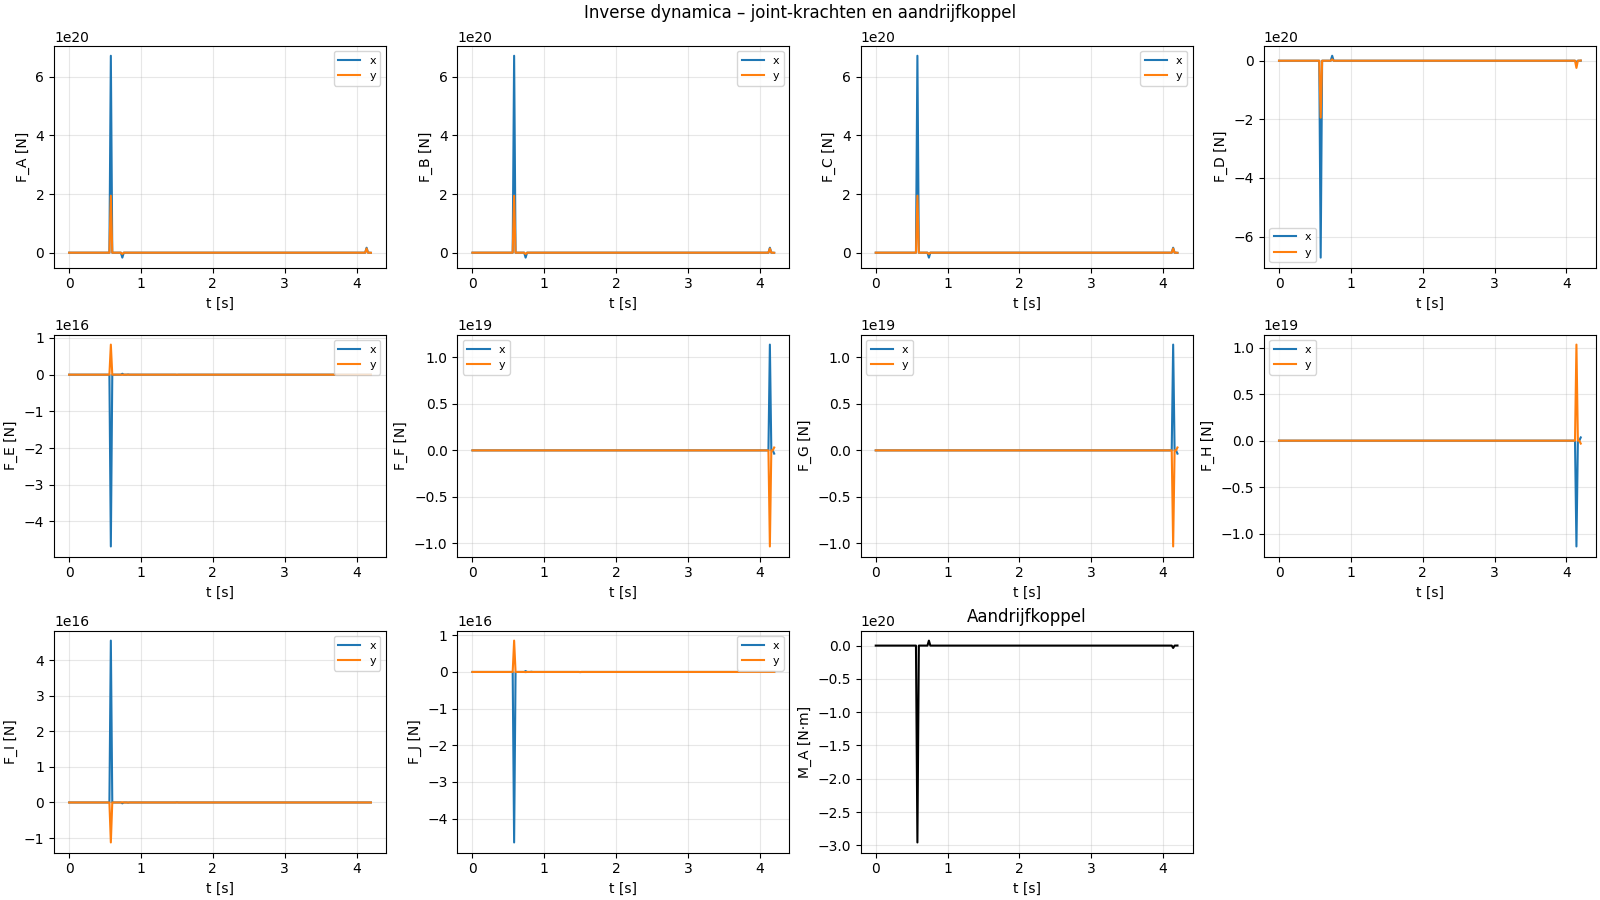

In [90]:
# === Plot reactiekrachten en aandrijfkoppel ===
fig, ax = plt.subplots(3, 4, figsize=(16, 9), constrained_layout=True)
forces = [('A',F_A),('B',F_B),('C',F_C),('D',F_D),
          ('E',F_E),('F',F_F),('G',F_G),('H',F_H),
          ('I',F_I),('J',F_J)]
for axis, (name, F) in zip(ax.flat, forces):
    axis.plot(t, F[:,0], label='x')
    axis.plot(t, F[:,1], label='y')
    axis.set_ylabel(f'F_{name} [N]'); axis.set_xlabel('t [s]')
    axis.legend(fontsize=8); axis.grid(alpha=0.3)

# Twee subplots over voor M_A
ax_m = ax.flat[10]
ax_m.plot(t, M_A, 'k-')
ax_m.set_ylabel('M_A [N·m]'); ax_m.set_xlabel('t [s]')
ax_m.set_title('Aandrijfkoppel'); ax_m.grid(alpha=0.3)
ax.flat[11].axis('off')

fig.suptitle('Inverse dynamica – joint-krachten en aandrijfkoppel')
plt.show()


### Onbalanskrachten (shaking force / shaking moment)
De som van de externe grondreacties zou — afgezien van de aandrijfkoppel-koppeling — moeten compenseren met de totale traagheidskracht van het mechanisme. Dit is een nuttige controle op de dynamische analyse.

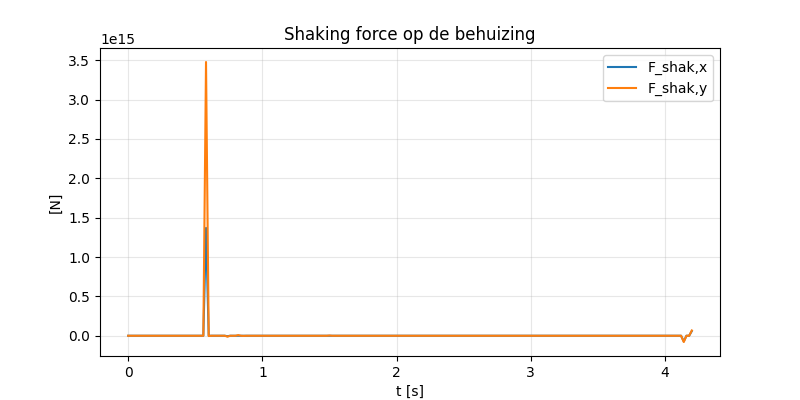

In [91]:
# Shaking-force = - (som van grondreacties op het mechanisme)
F_shak_x = -(F_A[:,0] + F_D[:,0] + F_H[:,0] + F_I[:,0])
F_shak_y = -(F_A[:,1] + F_D[:,1] + F_H[:,1] + F_I[:,1])

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(t, F_shak_x, label='F_shak,x')
ax.plot(t, F_shak_y, label='F_shak,y')
ax.set_xlabel('t [s]'); ax.set_ylabel('[N]')
ax.set_title('Shaking force op de behuizing'); ax.legend(); ax.grid(alpha=0.3)
plt.show()
